# 1. Libraries

In [1]:
import sys
sys.path.append("..")

In [2]:
# Project imports
from src.data_utils import create_full_dataset_for_participant
from src.engineered_features import create_features

# Data science libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Grid search for optimal window size and step size

For participant 4, the random seed is set to None, otherwise it is set to 42. This is experimental.

In [3]:
participant_id = 6
random_seed = 42 if not participant_id == 4 else None

In [4]:
window_sizes = [128, 256, 512, 1024, 2048]
step_sizes = [64, 128, 256, 512, 1024]

In [5]:
def grid_search_for_optimal_window_size(participant_id, window_sizes, step_sizes, random_seed=random_seed):
    for window_size in window_sizes:
        for step_size in step_sizes:
            X, y, feature_names = create_full_dataset_for_participant(participant_id, window_size, step_size)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, stratify=y, random_state=random_seed)
            model = RandomForestClassifier(n_estimators=100, random_state=random_seed)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            model_report = classification_report(y_test, y_pred, output_dict=True)
            accuracy = model_report['accuracy']
            print(f"Window Size: {window_size}, Step Size: {step_size}, Accuracy: {accuracy}")
            if accuracy > 0.95:
                print(f"Optimal window size found: {window_size} with step size {step_size}")
                print("Classification Report:\n", classification_report(y_test, y_pred))
                print("Confusion Matrix:")
                sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
                plt.xlabel("Predicted")
                plt.ylabel("True")
                plt.show()
                return X, y, window_size, step_size, model, feature_names

Window Size: 128, Step Size: 64, Accuracy: 0.9007352941176471
Window Size: 128, Step Size: 128, Accuracy: 0.9191176470588235
Window Size: 128, Step Size: 256, Accuracy: 0.855072463768116
Window Size: 128, Step Size: 512, Accuracy: 0.8333333333333334
Window Size: 128, Step Size: 1024, Accuracy: 0.7222222222222222
Window Size: 256, Step Size: 64, Accuracy: 0.9442379182156134
Window Size: 256, Step Size: 128, Accuracy: 0.9111111111111111
Window Size: 256, Step Size: 256, Accuracy: 0.8235294117647058
Window Size: 256, Step Size: 512, Accuracy: 0.9117647058823529
Window Size: 256, Step Size: 1024, Accuracy: 0.7222222222222222
Window Size: 512, Step Size: 64, Accuracy: 0.9847908745247148
Optimal window size found: 512 with step size 64
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       132
         1.0       1.00      0.97      0.98       131

    accuracy                           0.98       263
   macro avg      

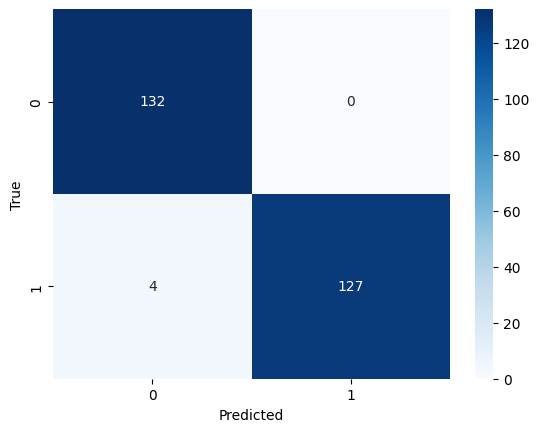

In [6]:
X, y, window_size, step_size, model, feature_names = grid_search_for_optimal_window_size(participant_id, window_sizes, step_sizes)

# 2. Feature selection via MDI

MDI (Mead Decrease in Impurity) scores for the features

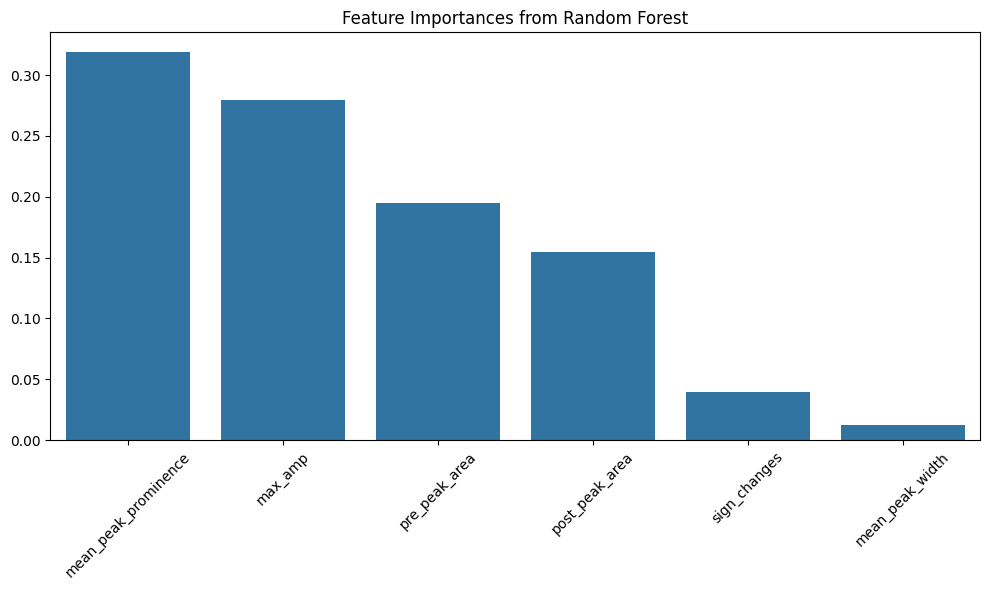

In [7]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=[feature_names[i] for i in sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()

Select the top 3 features

In [8]:
selected_features = [feature_names[i] for i in sorted_idx][:3]
df = pd.DataFrame(X, columns=feature_names)
df = df[selected_features].round(2)
df["label"] = y

Optionally, save the features.

In [9]:
# df.to_csv("../output/features_for_sirus.csv", index=False)

# 4. Rule-based classification using SIRUS

Now, we go to R to run the rule-extractor `SIRUS`, and get back the best fit rules.

In [10]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Push pandas DataFrame to R using context manager
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['features_for_sirus'] = ro.conversion.py2rpy(df)

# R code block
ro.r('''
require(sirus)

data <- features_for_sirus[, -ncol(features_for_sirus)]
data <- as.data.frame(data)
y <- features_for_sirus$label

sirus.m <- sirus.fit(data, y)
rules <- capture.output(sirus.print(sirus.m))
y_pred <- ifelse(sirus.predict(sirus.m, data) < 0.5, 0, 1)
''')

# Pull back predictions and rules
with localconverter(ro.default_converter + pandas2ri.converter):
    y_pred = np.array(ro.r('y_pred'), dtype=int)
    rules = list(ro.r('rules'))


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
c:\Users\SAMSUNG\Desktop\Github\Wearable-XAI\.venv\Lib\site-packages\rpy2\rinterface\__init__.py:1211: UserWarning: Environment variable "PATH" redefined by R and overriding existing variable. Current: "c:\Users\SAMSUNG\Desktop\Github\Wearable-XAI\.venv\Scripts;C:\Users\SAMSUNG\Desktop\Github\Wearable-XAI\.venv\Scripts;C:\Users\SAMSUNG\.local\share\mamba\envs\gnn;C:\Users\SAMSUNG\.local\share\mamba\envs\gnn\Library\mingw-w64\bin;C:\Users\SAMSUNG\.local\share\mamba\envs\gnn\Library\usr\bin;C:\Users\SAMSUNG\.local\share\mamba\envs\gnn\Library\bin;C:\Users\SAMSUNG\.local\share\mamba\envs\gnn\Scripts;C:\Users\SAMSUNG\.local\share\mamba\envs\gnn\bin;C:\Users\SAMSUNG\.local\share\mamba\condabin;C:\VulkanSDK\1.4.313.0\Bin;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files (x86)\Window

[1] "Number of trees:  1000  - Stability  93.18  %."
[1] "Number of trees:  2000  - Stability  94.43  %."
[1] "Number of trees:  3000  - Stability  95.62  %."


In [11]:
rules

[' [1] "Proportion of class 1 = 0.5 - Sample size n = 328"                                                 ',
 ' [2] "if mean_peak_prominence < 45.2 then 0.0366 (n=164) else 0.963 (n=164)"                             ',
 ' [3] "if max_amp < 115 then 0.037 (n=162) else 0.952 (n=166)"                                            ',
 ' [4] "if pre_peak_area < 1620 then 0.0617 (n=162) else 0.928 (n=166)"                                    ',
 ' [5] "if mean_peak_prominence >= 45.2 & pre_peak_area < 1620 then 0.615 (n=13) else 0.495 (n=315)"       ',
 ' [6] "if max_amp < 115 & pre_peak_area < 1620 then 0 (n=151) else 0.927 (n=177)"                         ',
 ' [7] "if mean_peak_prominence >= 45.2 & mean_peak_prominence < 68.4 then 0.818 (n=33) else 0.464 (n=295)"',
 ' [8] "if max_amp < 62.1 then 0 (n=128) else 0.82 (n=200)"                                                ',
 ' [9] "if mean_peak_prominence >= 45.2 & max_amp < 115 then 0.25 (n=8) else 0.506 (n=320)"                ',
 '[10] "if

Some of the most prominent rules for each participant. However, note that this manual rule pruning might not be stable. Whereas SIRUS is proven to be stable.

In [12]:
# def rule_for_participant(window_features, participant_id):
#     match participant_id:
#         case 0:
#             return window_features['mean_peak_prominence'] >= 59.5 # 90% accuracy -> 93% accuracy
#         case 1:
#             return window_features['max_amp'] >= 84.2 # 94% accuracy -> 90% accuracy
#         case 2:
#             return window_features['mean_peak_width'] < 20.9 # 95% accuracy -> 91% accuracy
#         case 3:
#             return window_features['max_amp'] >= 31.9 # 94% accuracy -> 95% accuracy
#         case 5:
#             return window_features['sign_changes'] > 178 # 100% accuracy -> 100% accuracy
#         case 6:
#             return window_features['mean_peak_prominence'] >= 45.1 # 91% accuracy -> 94% accuracy
#         case 7:
#             return window_features['mean_peak_prominence'] < 94.8 # 97% accuracy -> 97% accuracy
#         case 8:
#             return window_features['max_amp'] >= 75.2 # 98% accuracy -> 96% accuracy
#         case 9:
#             return window_features['max_amp'] < 71.9 # 97% accuracy -> 98% accuracy
#         case 10:
#             return window_features['pre_peak_area'] < 2550 # 91% accuracy -> 92% accuracy



# rule = lambda window_features: rule_for_participant(window_features, participant_id)

# df['rule_label'] = df.apply(rule, axis=1).astype(int)    

We take the averaged prediction of the rules, given by SIRUS.

In [13]:
df["rule_label"] = y_pred

In [14]:
df

,mean_peak_prominence,max_amp,pre_peak_area,label,rule_label
0,36.16,70.03,1721.42,0.0,1
1,37.57,70.03,1721.42,0.0,1
2,35.27,53.47,1048.73,0.0,0
3,36.85,53.47,1048.73,0.0,0
4,38.74,53.47,1048.73,0.0,0
...,...,...,...,...,...
323,117.52,263.06,4625.69,1.0,1
324,121.23,263.06,4625.69,1.0,1
325,118.47,263.06,4625.69,1.0,1
326,114.22,263.06,4625.69,1.0,1


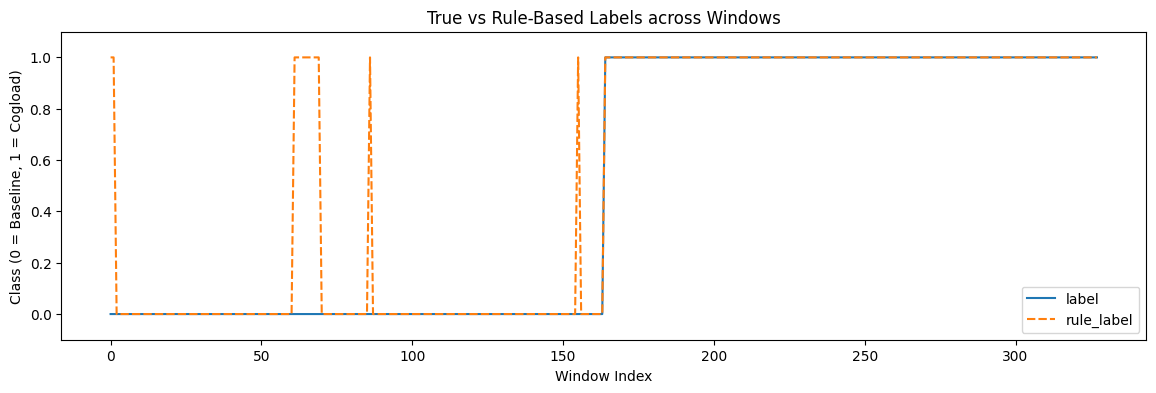

In [15]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=df[['label', 'rule_label']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

In [16]:
accuracy = (df["label"] == df["rule_label"]).mean()
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96
